In [123]:
# library for feature engineering and EDA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd

# library for statistic
from scipy.stats import chi2_contingency

# library for machine learning
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

import copy
%matplotlib inline

# 6 카이제곱 검정과 다중공선성 제거를 통한
# EDA 자동화

- 카이제곱 검정의 독립성 검정을 통하여, 타겟과 독립적으로 작동하는 feature는 제거
- 기계화된 다중공선성 제거를 통해 연속형 변수의 독립성을 확보
- 이후 box-cox 변환 사용
- 이후 가벼운 ml 모델을 통해 자동화된 eda 전 후 metric 비교

## 6.1 Data Load

In [124]:
# 데이터셋은 _5_EDA와 동일합니다.

random_state = 1234
raw_df = pd.read_csv("data/german_credit_risk_data.csv", sep=";")
df = copy.deepcopy(raw_df)
df = df.dropna(how="any")
print("중복된 항목 수 :", len(df[df.duplicated()]))
df.head()

중복된 항목 수 : 0


,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,...,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2


In [125]:
df.columns

Index(['Creditability', 'Account_Balance', 'Duration_of_Credit_monthly',
       'Payment_Status_of_Previous_Credit', 'Purpose', 'Credit_Amount',
       'Value_Savings_Stocks', 'Length_of_current_employment',
       'Instalment_per_cent', 'Sex_Marital_Status', 'Guarantors',
       'Duration_in_Current_address', 'Most_valuable_available_asset',
       'Age_years', 'Concurrent_Credits', 'Type_of_apartment',
       'No_of_Credits_at_this_Bank', 'Occupation', 'No_of_dependents',
       'Telephone', 'Foreign_Worker'],
      dtype='object')

In [126]:
print(df.columns)

continuous_columns = [
    "Duration_of_Credit_monthly",
    "Credit_Amount",
    "Age_years",
]

for column in continuous_columns:
    print(f"Checking: {column}") 
    if column in list(df.columns):
        print(column)


Index(['Creditability', 'Account_Balance', 'Duration_of_Credit_monthly',
       'Payment_Status_of_Previous_Credit', 'Purpose', 'Credit_Amount',
       'Value_Savings_Stocks', 'Length_of_current_employment',
       'Instalment_per_cent', 'Sex_Marital_Status', 'Guarantors',
       'Duration_in_Current_address', 'Most_valuable_available_asset',
       'Age_years', 'Concurrent_Credits', 'Type_of_apartment',
       'No_of_Credits_at_this_Bank', 'Occupation', 'No_of_dependents',
       'Telephone', 'Foreign_Worker'],
      dtype='object')
Checking: Duration_of_Credit_monthly
Duration_of_Credit_monthly
Checking: Credit_Amount
Credit_Amount
Checking: Age_years
Age_years


In [127]:
continuous_columns = [
    "Duration_of_Credit_monthly",
    "Credit_Amount",
    "Age_years",
]

In [128]:
# 그래서 데이터를 직접 살핀다음에, continuous와 discrete으로 나눠야 합니다.

threshold = 30
discrete_columns = []
continuous_columns = []

for column_name in list(df.columns):
    if len(df[column_name].unique()) > threshold:
        continuous_columns.append(column_name)
        df[column_name] = df[column_name].astype("int64")

    else:
        discrete_columns.append(column_name)
        df[column_name] = df[column_name].astype("object")

list_categorical_columns = list(df.select_dtypes(include=['object']).columns)
list_numeric_columns = list(df.select_dtypes(include=['int64']).columns)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Creditability                      1000 non-null   object
 1   Account_Balance                    1000 non-null   object
 2   Duration_of_Credit_monthly         1000 non-null   int64 
 3   Payment_Status_of_Previous_Credit  1000 non-null   object
 4   Purpose                            1000 non-null   object
 5   Credit_Amount                      1000 non-null   int64 
 6   Value_Savings_Stocks               1000 non-null   object
 7   Length_of_current_employment       1000 non-null   object
 8   Instalment_per_cent                1000 non-null   object
 9   Sex_Marital_Status                 1000 non-null   object
 10  Guarantors                         1000 non-null   object
 11  Duration_in_Current_address        1000 non-null   object
 12  Most_va

## 6.2 카이제곱 적합도 검정(데이터 확인 용)

- 상황: 하나의 feature(ordinal, nominal)에 대하여 class의 수학적 발생 확률을 알고 있을 때, 샘플링이 잘 되었는지 확인할 때 사용

Telephone
1    596
2    404
Name: count, dtype: int64


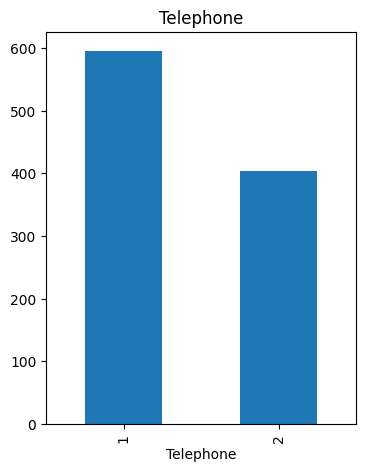

In [129]:
plt.figure(figsize=(4,4))
print(df["Telephone"].value_counts())
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.3, wspace=0.2)
df["Telephone"].value_counts().sort_index().plot(kind='bar')
plt.title("Telephone")
plt.show()

In [130]:
import scipy.stats as stats

observed = df['Telephone'].value_counts().values
nums = 2
alpha = 0.05

n = sum(observed) 
expected = [n / nums] * nums  
chi2_stat, p_value = stats.chisquare(f_obs=observed, f_exp=expected)

critical_value = stats.chi2.ppf(1 - alpha, df=nums-1) 
print(observed)
print("Null Hypothesis: 전화기 유무 확률은 1/2로 동일하다")
print("Alternative Hypothesis: 전화기 유무 확률은 1/2로 동일하지 않습니니다.")

print(f"카이제곱 검정 통계량: {chi2_stat:.4f}")
print(f"기각값(임계값, critical value): {critical_value:.4f}")

if chi2_stat > critical_value:
    print("귀무가설을 기각합니다.")
    print("전화기 유무 확률은 1/2로 동일하지 않습니다.")
else:
    print("귀무가설을 기각할 수 없습니다.")
    print("전화기 유무 확률이 동일하지 않다고 볼 근거가 없습니다.")


[596 404]
Null Hypothesis: 전화기 유무 확률은 1/2로 동일하다
Alternative Hypothesis: 전화기 유무 확률은 1/2로 동일하지 않습니니다.
카이제곱 검정 통계량: 36.8640
기각값(임계값, critical value): 3.8415
귀무가설을 기각합니다.
전화기 유무 확률은 1/2로 동일하지 않습니다.


## 6.3 카이제곱 독립성 검정

- 상황: 두 개의 feature(ordinal, nominal)에 대하여, 두 집단이 독립적으로 작동하는지 확인할 때 사용.

- 가설: 타겟과 독립적으로 움직이는 칼럼은 사용할 필요 없을 것이다. 

In [131]:
sample_df = pd.crosstab(df["Creditability"], df["Type_of_apartment"])
sample_df

Type_of_apartment,1,2,3
Creditability,,,
0,70,186,44
1,109,528,63


In [132]:
statistic, pvalue, _, _ = chi2_contingency(sample_df)
alpha = 0.05

print("Null Hypothesis: 두 칼럼은 독립적이다.")
print("Alternative Hypothesis: 두 칼럼은 종속적이다")

print(f"카이제곱 검정 통계량: {chi2_stat:.4f}")
print(f"기각값(임계값, critical value): {critical_value:.4f}")

if pvalue < alpha:
    print("귀무가설을 기각합니다.")
    print("두 칼럼은 종속적입니다.")
else:
    print("귀무가설을 기각할 수 없습니다.")
    print("두 칼럼이 독립적이지 않을 근거는 없습니다.")

Null Hypothesis: 두 칼럼은 독립적이다.
Alternative Hypothesis: 두 칼럼은 종속적이다
카이제곱 검정 통계량: 36.8640
기각값(임계값, critical value): 3.8415
귀무가설을 기각합니다.
두 칼럼은 종속적입니다.


In [133]:
from collections import defaultdict

chi_processed = defaultdict(lambda : {"statictic":0.0,"pvalue":0.0})

for column_name in list_categorical_columns:
    statistic, pvalue, _, _ = chi2_contingency(pd.crosstab(df["Creditability"], df[column_name]))
    chi_processed[column_name]['statistic'] = round(statistic,2)
    chi_processed[column_name]['pvalue'] = round(pvalue,2)
    
chi_processed_df = pd.DataFrame(chi_processed).T
processed_classifical_columns = list(chi_processed_df[chi_processed_df['pvalue']<= alpha].index)
display(chi_processed_df)

,statictic,pvalue,statistic
Creditability,0.0,0.00,995.24
Account_Balance,0.0,0.00,123.72
Payment_Status_of_Previous_Credit,0.0,0.00,61.69
Purpose,0.0,0.00,33.36
Value_Savings_Stocks,0.0,0.00,36.10
Length_of_current_employment,0.0,0.00,18.37
Instalment_per_cent,0.0,0.14,5.48
Sex_Marital_Status,0.0,0.02,9.61
Guarantors,0.0,0.04,6.65
Duration_in_Current_address,0.0,0.86,0.75


## 6.4 pearson 상관계수(데이터 참고용)

In [134]:
import numpy as np
example_features = list_numeric_columns[0]
target_feature = 'Creditability'

X = np.array(df[example_features].to_list())
Y = np.array(df[target_feature].to_list())

# ddof = Delta degree of freedom
# 현재는 sample data를 가지고 하는 것이기 때문에 ddof = 1로 둬야 합니다. 
# sample data => n-1 / polulation => n
std_X = np.std(X, ddof=1)
std_Y = np.std(Y, ddof=1)

# 표본 공분산 (bias=False => n-1)
cov_matrix = np.cov(X, Y, bias=False)
print(cov_matrix)

[[145.41500601  -1.18828829]
 [ -1.18828829   0.21021021]]


In [135]:
cov_XY = cov_matrix[0, 1]

# 피어슨 상관계수
r = cov_XY / (std_X * std_Y)

print("표준편차(X):", std_X)
print("표준편차(Y):", std_Y)
print("공분산(X, Y):", cov_XY)
print("피어슨 상관계수:", r)

표준편차(X): 12.058814452756375
표준편차(Y): 0.4584868702702513
공분산(X, Y): -1.1882882882882886
피어슨 상관계수: -0.21492666544189076


<Axes: >

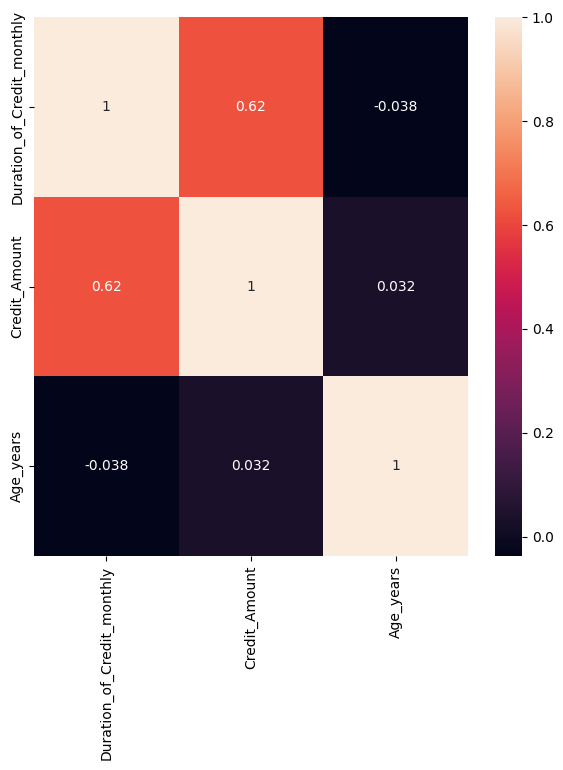

In [136]:
plt.figure(figsize=(7,7))
sns.heatmap(df[list_numeric_columns].corr(), annot=True)

## 6.5 Q_Q plot을 통한 데이터 검정

- box-cox 변환을 했을 때 더욱 정규화가 잘 되고 있음을 알 수 있음.

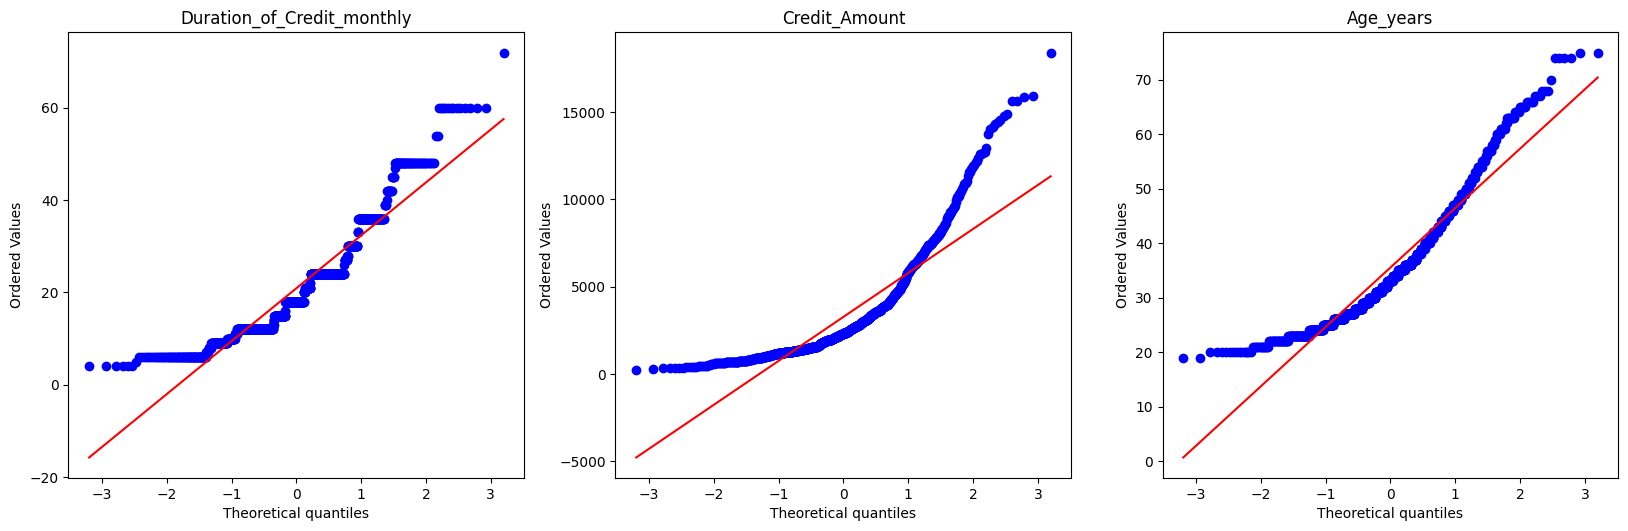

In [137]:
# numeric column 별 분포 확인
plt.figure(figsize=(20,10))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.2, wspace=0.2)
for column_name in list_numeric_columns:
    plt.subplot(2,3,x)
    x = x+1
    stats.probplot(df[column_name], dist=stats.norm, plot=plt)
    plt.title(column_name)
plt.show()

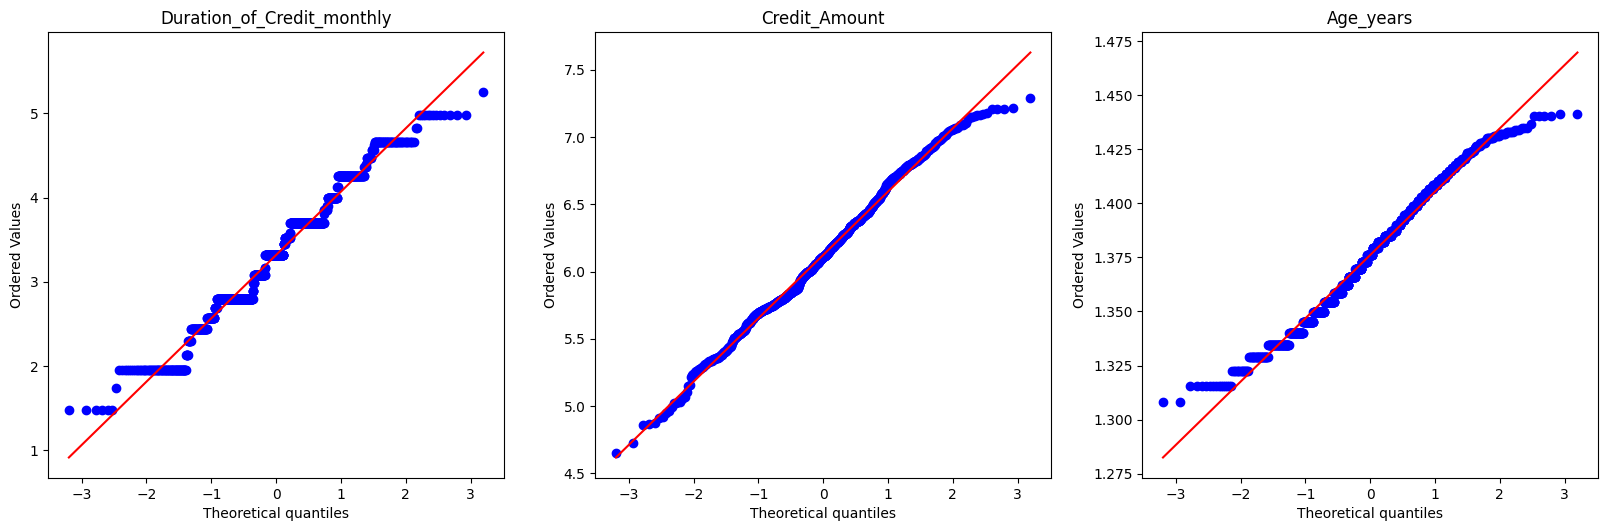

In [138]:
# numeric column 별 분포 확인
plt.figure(figsize=(20,10))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.2, wspace=0.2)
for column_name in list_numeric_columns:
    plt.subplot(2,3,x)
    x = x+1
    stats.probplot(stats.boxcox(df[column_name])[0], dist=stats.norm, plot=plt)
    plt.title(column_name)
plt.show()

# 6.6 다중 공선성 제거
- VIF 가 보통 10 이상이면 연속형 변수 간에 상관관계가 짙다고 간주합니다.
- 따라서 10이 넘어가는 칼럼이 없을 때까지 지우는 전략을 채택합니다.

In [139]:
import numpy as np

example_target_column = "Duration_of_Credit_monthly"
example_feature_columns = list_numeric_columns[1:]

y = df[example_target_column].to_numpy()
X = df[example_feature_columns].to_numpy()

# 선형 회귀를 하기 위한 정규방정식
theta = (np.linalg.inv(X.T @ X) @ X.T @ y)
y_pred = X @ theta

# 평균에 의한 기준 설명력
sst = np.sum((y - np.mean(y)) ** 2)
# 선형 회귀에 의한 설명력력
ssr = np.sum((y - y_pred) ** 2)
r_squared = 1 - (ssr / sst)

vif = 1 / (1 - r_squared)
print(vif)

1.380410285380077


In [140]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from copy import copy

processed_numeric_columns = copy(list_numeric_columns)
flag = True

while flag:
    X = df[processed_numeric_columns]
    vif = pd.DataFrame()
    vif["feature"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    vif = pd.DataFrame(vif.sort_values(by="VIF", ascending=False)).reset_index(drop=True)
    if vif.loc[0,"VIF"] < 10:
        flag=False
    processed_numeric_columns = vif.iloc[1:]['feature']

processed_numeric_columns = processed_numeric_columns.tolist()

In [141]:
from copy import deepcopy

processed_df = deepcopy(df)
for column_name in processed_numeric_columns:
    processed_df[column_name] = stats.boxcox(processed_df[column_name])[0]

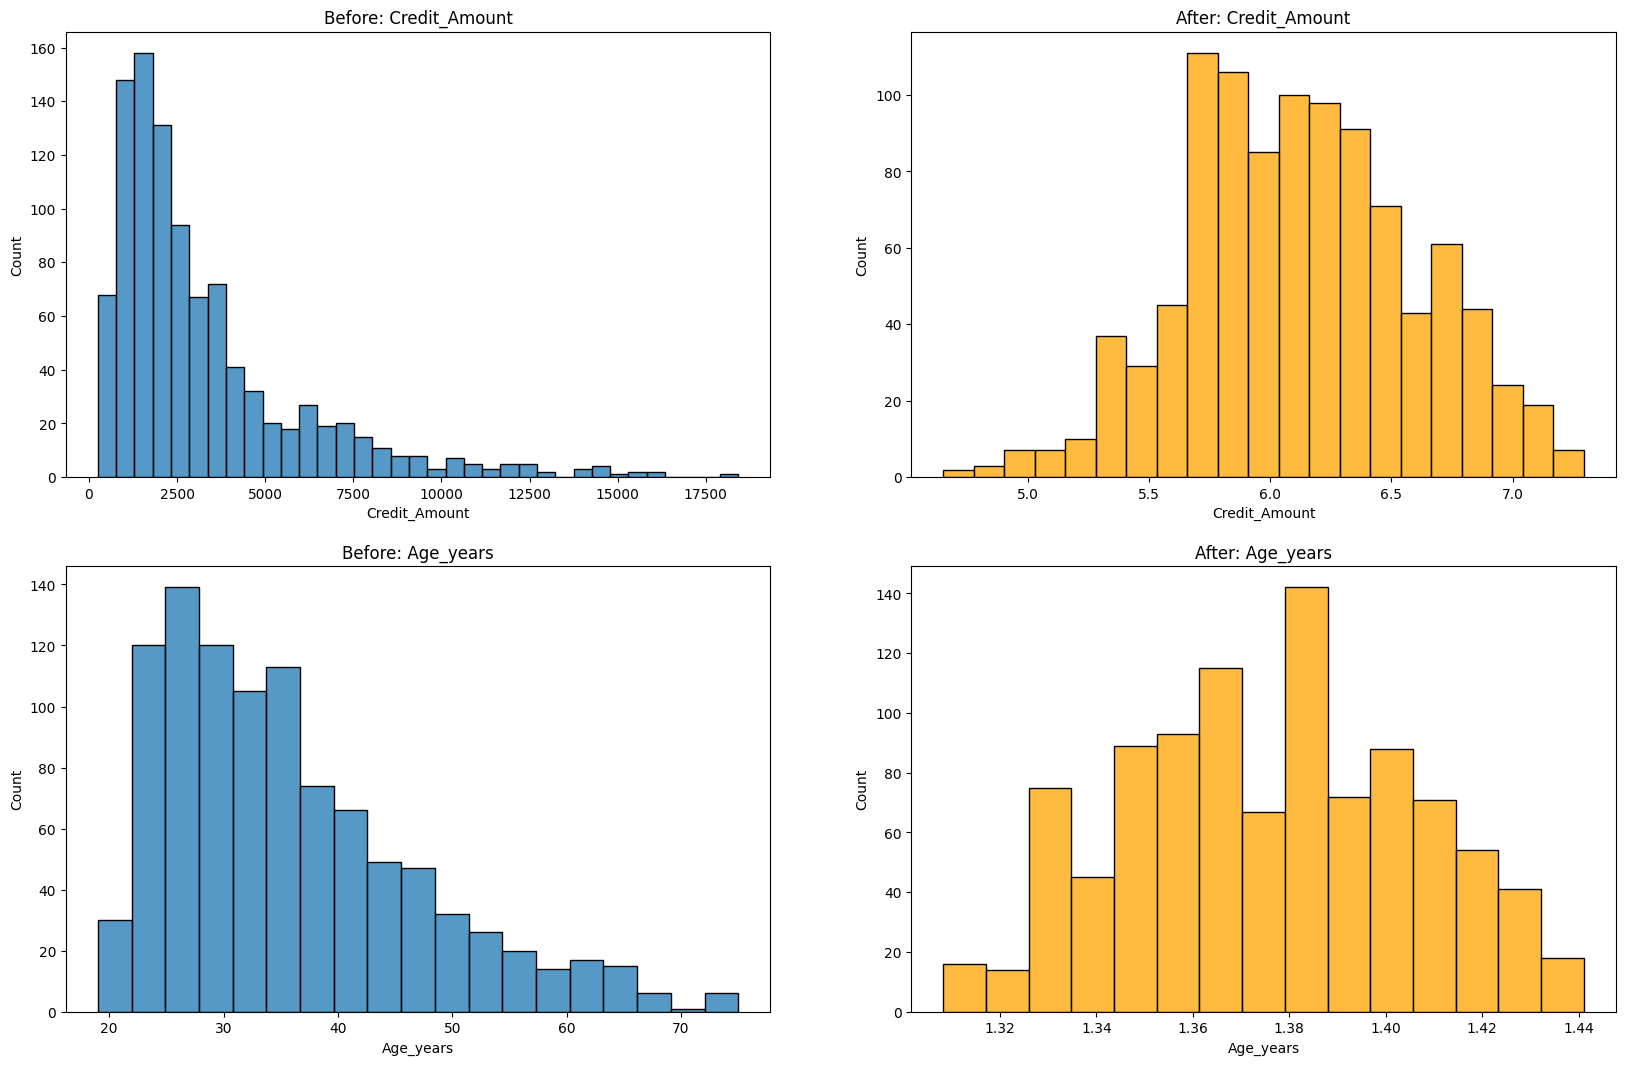

In [142]:
# numeric column 별 분포 확인
plt.figure(figsize=(20,10))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.2, wspace=0.2)
for column_name in processed_numeric_columns:
    plt.subplot(2,2,x)
    sns.histplot(x=column_name, data=df)
    plt.title("Before: " + column_name)
    x = x+1
    plt.subplot(2,2,x)
    sns.histplot(x=column_name, data=processed_df, color='orange')
    plt.title("After: " + column_name)
    x = x+1
plt.show()

## 6.7 Metric 비교

In [143]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

target = 'Creditability'
selected_features = processed_classifical_columns + processed_numeric_columns
selected_features.remove(target)

control_features = list(df.columns)
control_features.remove(target)

# 특성과 타겟 준비
X_selected = df[selected_features]  
y_selected = df[target].astype(int)          

X_control = df[control_features]  
y_control = df[target].astype(int)           

# 학습/테스트 분할
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(X_selected, y_selected, test_size=0.2, random_state=42)
X_train_control, X_test_control, y_train_control, y_test_control = train_test_split(X_control, y_control, test_size=0.2, random_state=42)

# 모델 학습
clf_selected = DecisionTreeClassifier(random_state=42)
clf_control = DecisionTreeClassifier(random_state=42)
clf_selected.fit(X_train_selected, y_train_selected)
clf_control.fit(X_train_control, y_train_control)

# 예측
y_pred_selected = clf_selected.predict(X_test_selected)
y_prob_selected = clf_selected.predict_proba(X_test_selected)[:, 1]

y_pred_control = clf_control.predict(X_test_control)
y_prob_control = clf_control.predict_proba(X_test_control)[:, 1]

# 평가 지표
accuracy_selected = accuracy_score(y_test_selected, y_pred_selected)
precision_selected = precision_score(y_test_selected, y_pred_selected, zero_division=0)
recall_selected = recall_score(y_test_selected, y_pred_selected)
f1_selected = f1_score(y_test_selected, y_pred_selected)
auc_selected = roc_auc_score(y_test_selected, y_prob_selected)

accuracy_control = accuracy_score(y_test_control, y_pred_control)
precision_control = precision_score(y_test_control, y_pred_control, zero_division=0)
recall_control = recall_score(y_test_control, y_pred_control)
f1_control = f1_score(y_test_control, y_pred_control)
auc_control = roc_auc_score(y_test_control, y_prob_control)

print(f"Accuracy : {accuracy_selected:.4f}")
print(f"Precision: {precision_selected:.4f}")
print(f"Recall   : {recall_selected:.4f}")
print(f"F1 Score : {f1_selected:.4f}")
print(f"AUC-ROC  : {auc_selected:.4f}")
print("-"*10)
print(f"Accuracy : {accuracy_control:.4f}")
print(f"Precision: {precision_control:.4f}")
print(f"Recall   : {recall_control:.4f}")
print(f"F1 Score : {f1_control:.4f}")
print(f"AUC-ROC  : {auc_control:.4f}")

Accuracy : 0.6600
Precision: 0.7465
Recall   : 0.7681
F1 Score : 0.7571
AUC-ROC  : 0.5937
----------
Accuracy : 0.7250
Precision: 0.8320
Recall   : 0.7536
F1 Score : 0.7909
AUC-ROC  : 0.7075


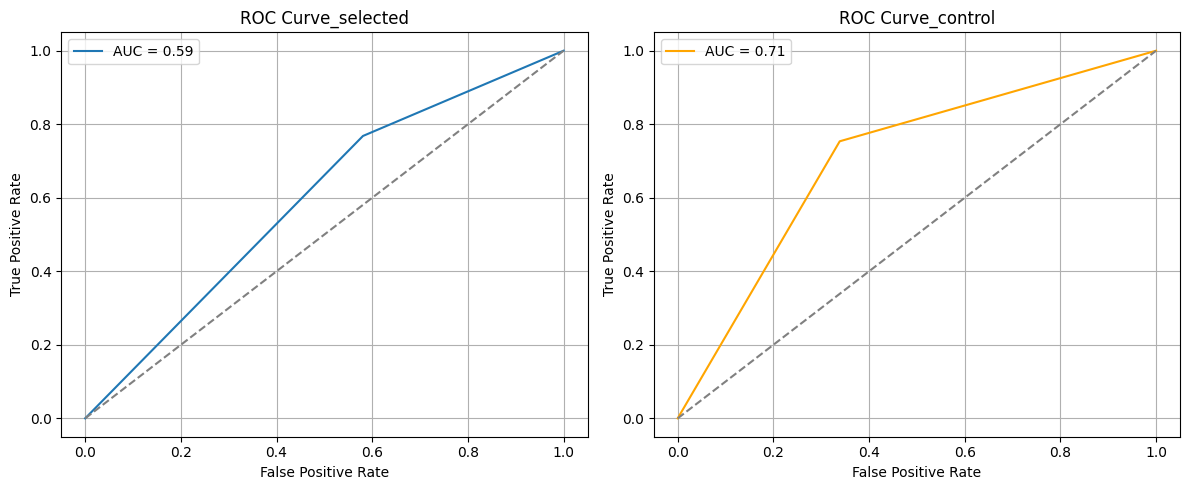

In [144]:
fpr_control, tpr_control, _ = roc_curve(y_test_control, y_prob_control)
fpr_selected, tpr_selected, _ = roc_curve(y_test_selected, y_prob_selected)

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(fpr_selected, tpr_selected, label=f"AUC = {auc_selected:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve_selected")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(fpr_control, tpr_control, label=f"AUC = {auc_control:.2f}", color="orange")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve_control")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
